# **Library**

In [1]:
import pandas as pd
import random
import numpy as np
import torch
import gdown
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# model indobertweet
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW # Import AdamW dari torch.optim
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.nn import CrossEntropyLoss

# model lstm
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

# model ml ekstraksi fitur
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print('Ada GPU yang tersedia. Menggunakan GPU untuk pelatihan.')
else:
    device = torch.device("cpu")
    print('Tidak ada GPU yang tersedia. Menggunakan CPU untuk pelatihan.')

Ada GPU yang tersedia. Menggunakan GPU untuk pelatihan.


Set Seed for Reproducibility

In [3]:
def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(42)
print("Seed telah diatur untuk reproduktibilitas.")

Seed telah diatur untuk reproduktibilitas.


**Konfigurasi**

In [4]:
# Dataset
FILE_ID = '1zCIipCHY3xvFtgGeFBMLWATXsY96czdi'
INPUT_FILE = 'Slowliving_Label.csv'

# **Load Dataset**

In [5]:
gdown.download(id=FILE_ID, output=INPUT_FILE, quiet=False)
df = pd.read_csv(INPUT_FILE)
display(df.head(1))
df.info()

Downloading...
From: https://drive.google.com/uc?id=1zCIipCHY3xvFtgGeFBMLWATXsY96czdi
To: /content/Slowliving_Label.csv
100%|██████████| 1.02M/1.02M [00:00<00:00, 60.0MB/s]


,full_text,sentiment,slang,stemming,label
0,bulan di batam ngajarin aku kalo menyesuaikan ...,positif,bulan di batam ngajarin saya kalo menyesuaik...,bulan di batam ngajarin saya kalo sesuai phase...,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  3417 non-null   object
 1   sentiment  3417 non-null   object
 2   slang      3417 non-null   object
 3   stemming   3417 non-null   object
 4   label      3417 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 133.6+ KB


# **EDA**

/tmp/ipython-input-4118028567.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


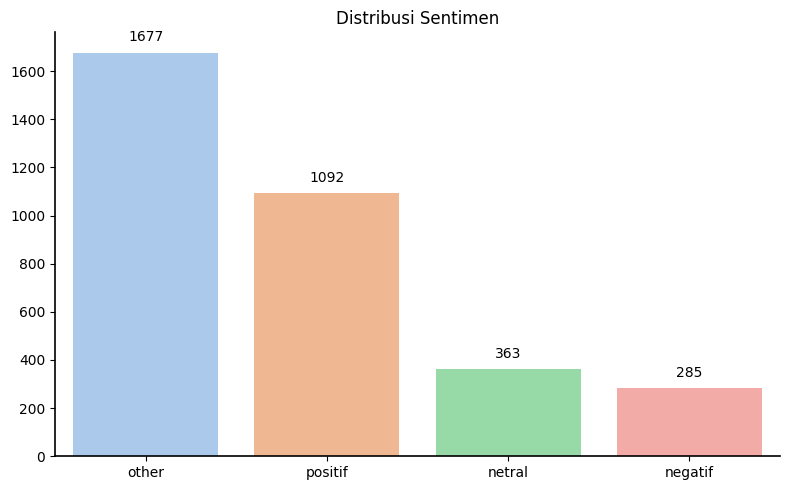

In [6]:
# Mapping label ke nama sentimen
label_to_sentiment = {0: 'netral', 1: 'positif', 2: 'negatif', 3: 'other'}
df['sentiment'] = df['label'].map(label_to_sentiment)

# Hitung jumlah per sentimen
label_counts = df['sentiment'].value_counts()

# Plot minimalis
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

# Hilangkan elemen tambahan
plt.title('Distribusi Sentimen')
ax.set_xlabel("")            # Hilangkan label sumbu X
ax.set_ylabel("")            # Hilangkan label sumbu Y
ax.legend([],[], frameon=False)  # Hilangkan legend

# Tambahkan garis sumbu X dan Y saja
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (Opsional) Tambahkan garis dasar sumbu X/Y agar tetap terlihat
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# (Opsional) Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.02, str(value),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

==== Prepare Data ====

In [7]:
df = df[['sentiment', 'stemming', 'label']]
print("\n✅ Dataset dimuat. Contoh:")
display(df.head(2))
df.info()


✅ Dataset dimuat. Contoh:


,sentiment,stemming,label
0,positif,bulan di batam ngajarin saya kalo sesuai phase...,1
1,netral,sekali sekali slow living,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  3417 non-null   object
 1   stemming   3417 non-null   object
 2   label      3417 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 80.2+ KB


==== Skema Label Biner ====

In [8]:
df['skema_label'] = df['label'].apply(lambda x: 0 if x == 3 else 1)
display(df.head(2))
df.info()

,sentiment,stemming,label,skema_label
0,positif,bulan di batam ngajarin saya kalo sesuai phase...,1,1
1,netral,sekali sekali slow living,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sentiment    3417 non-null   object
 1   stemming     3417 non-null   object
 2   label        3417 non-null   int64 
 3   skema_label  3417 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 106.9+ KB


# **Split Data**

70 15 15

In [9]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['stemming'], df['skema_label'], test_size=0.3, random_state=42, stratify=df['label']
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

In [10]:
# df_train menampung hasil dari xtrain
df_train = pd.DataFrame({'stemming': train_texts, 'skema_label': train_labels})

# Tambahkan kolom 'sentiment' ke df_train dengan memetakan 'label' ke 'sentiment' dari dataframe df/utama
label_to_sentiment = df.set_index('skema_label')['sentiment'].to_dict()
df_train['sentiment'] = df_train['skema_label'].map(label_to_sentiment)

print(f"\n📊 Jumlah data train: {len(df_train)} | val: {len(val_texts)} | test: {len(test_texts)}")
display(df_train.head(2))
df_train.info()


📊 Jumlah data train: 2391 | val: 513 | test: 513


,stemming,skema_label,sentiment
3163,pen jadi pegawai negeri sipil pemkot slow livi...,1,netral
1941,panas banget hari minum es tentu sangat enak,0,other


<class 'pandas.core.frame.DataFrame'>
Index: 2391 entries, 3163 to 1100
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   stemming     2391 non-null   object
 1   skema_label  2391 non-null   int64 
 2   sentiment    2391 non-null   object
dtypes: int64(1), object(2)
memory usage: 74.7+ KB


/tmp/ipython-input-67664641.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


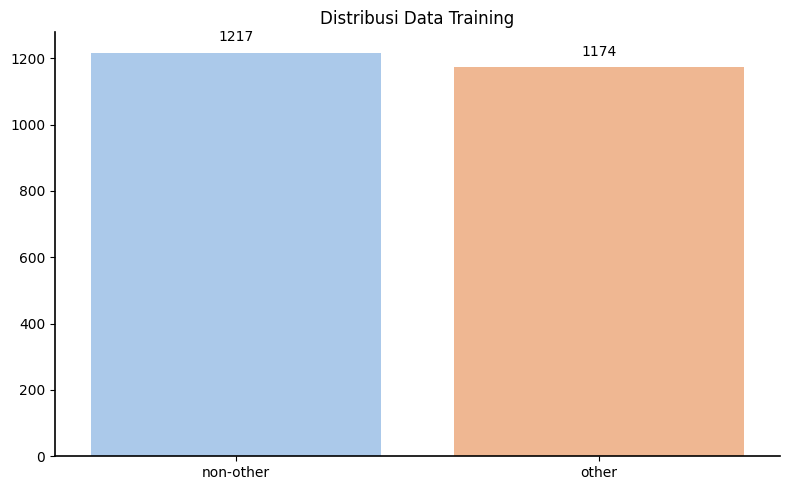

In [11]:
skema_label_to_sentiment = {0: 'other', 1: 'non-other'}
df_train['sentiment'] = df_train['skema_label'].map(skema_label_to_sentiment)

# Hitung jumlah sentimen
label_counts = df_train['sentiment'].value_counts()

# Plot minimalis
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

# Hilangkan elemen tambahan
plt.title('Distribusi Data Training')
ax.set_xlabel("")            # Hilangkan label sumbu X
ax.set_ylabel("")            # Hilangkan label sumbu Y
ax.legend([],[], frameon=False)  # Hilangkan legend

# Tambahkan garis sumbu X dan Y saja
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (Opsional) Tambahkan garis dasar sumbu X/Y agar tetap terlihat
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# (Opsional) Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.02, str(value),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# **Model IndoBERTweet**

### **Tokenize Data Loader**

In [12]:
# Menginisialisasi tokenizer IndoBERTweet
print("\nMenginisialisasi tokenizer IndoBERTweet...")
tokenizer = AutoTokenizer.from_pretrained('indolem/indobertweet-base-uncased')

# Fungsi untuk tokenisasi dan encoding data
def encode_data(tokenizer, texts, labels):
    input_ids = []
    attention_masks = []
    for text in texts:
        encoded_dict = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=128,  # Menetapkan panjang maksimum sequence
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(labels)
    return TensorDataset(input_ids, attention_masks, labels)

# Menerapkan fungsi encoding ke setiap set data
train_dataset = encode_data(tokenizer, df_train['stemming'].tolist(), df_train['skema_label'].tolist())
val_dataset = encode_data(tokenizer, val_texts.tolist(), val_labels.tolist())
test_dataset = encode_data(tokenizer, test_texts.tolist(), test_labels.tolist())

# Membuat DataLoader untuk memproses data dalam batch
batch_size = 16
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)


Menginisialisasi tokenizer IndoBERTweet...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

### **Load Model**

In [13]:
num_labels = 2
model = AutoModelForSequenceClassification.from_pretrained(
    'indolem/indobertweet-base-uncased',
    num_labels=num_labels,
    output_attentions=False,
    output_hidden_states=False
)
model.to(device)

# Mengatur optimizer dan scheduler dengan learning rate dan epsilon yang ditentukan
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
epochs = 4
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.5)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### **Training**

In [14]:
print("\n--- Memulai Pelatihan ---")
# Menyimpan riwayat metrik untuk visualisasi
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience = 1
patience_counter = 0
best_model_state = None

for epoch_i in range(epochs):
    print(f"\n======== Epoch {epoch_i + 1} / {epochs} ========")

    # Mode pelatihan (training)
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0

    for step, batch in enumerate(train_dataloader):
        if step % 50 == 0 and not step == 0:
            print(f'  Batch {step} dari {len(train_dataloader)}.')

        # Memindahkan batch data ke device (GPU/CPU)
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()

        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        logits = outputs.logits

        total_train_loss += loss.item()

        # Menghitung akurasi batch
        preds = torch.argmax(logits, dim=1)
        total_train_accuracy += (preds == b_labels).sum().item() / len(b_labels)

        loss.backward() # Propagasi balik
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Mencegah exploding gradients
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_accuracy / len(train_dataloader)

    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)

    print(f"  Rata-rata loss pelatihan: {avg_train_loss:.2f}")
    print(f"  Rata-rata akurasi pelatihan: {avg_train_acc:.2f}")

    # Mode evaluasi (validation)
    model.eval()
    total_eval_loss = 0
    total_eval_accuracy = 0

    for batch in val_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

        loss = outputs.loss
        logits = outputs.logits
        total_eval_loss += loss.item()

        # Menghitung akurasi validasi
        preds = torch.argmax(logits, dim=1)
        total_eval_accuracy += (preds == b_labels).sum().item() / len(b_labels)

    avg_val_loss = total_eval_loss / len(val_dataloader)
    avg_val_acc = total_eval_accuracy / len(val_dataloader)

    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)

    print(f"  Rata-rata loss validasi: {avg_val_loss:.2f}")
    print(f"  Rata-rata akurasi validasi: {avg_val_acc:.2f}")

    # Implementasi Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
        print("  Loss validasi menurun. Menyimpan model terbaik.")
    else:
        patience_counter += 1
        print(f"  Loss validasi tidak menurun. Patience counter: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"  Early stopping! Pelatihan dihentikan setelah {epoch_i + 1} epoch.")
            break

# Muat kembali model terbaik yang telah disimpan
if best_model_state is not None:
    model.load_state_dict(best_model_state)


--- Memulai Pelatihan ---

======== Epoch 1 / 4 ========


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

  Batch 50 dari 150.
  Batch 100 dari 150.
  Rata-rata loss pelatihan: 0.27
  Rata-rata akurasi pelatihan: 0.90
  Rata-rata loss validasi: 0.08
  Rata-rata akurasi validasi: 0.98
  Loss validasi menurun. Menyimpan model terbaik.

======== Epoch 2 / 4 ========
  Batch 50 dari 150.
  Batch 100 dari 150.
  Rata-rata loss pelatihan: 0.08
  Rata-rata akurasi pelatihan: 0.98
  Rata-rata loss validasi: 0.07
  Rata-rata akurasi validasi: 0.98
  Loss validasi menurun. Menyimpan model terbaik.

======== Epoch 3 / 4 ========
  Batch 50 dari 150.
  Batch 100 dari 150.
  Rata-rata loss pelatihan: 0.06
  Rata-rata akurasi pelatihan: 0.98
  Rata-rata loss validasi: 0.07
  Rata-rata akurasi validasi: 0.98
  Loss validasi tidak menurun. Patience counter: 1/1
  Early stopping! Pelatihan dihentikan setelah 3 epoch.


apikey a5153cecda5fef1b45867e96aa08c5cc24f8771a

### **Evaluasi Model**


Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       252
           1       0.97      0.98      0.98       261

    accuracy                           0.97       513
   macro avg       0.97      0.97      0.97       513
weighted avg       0.97      0.97      0.97       513



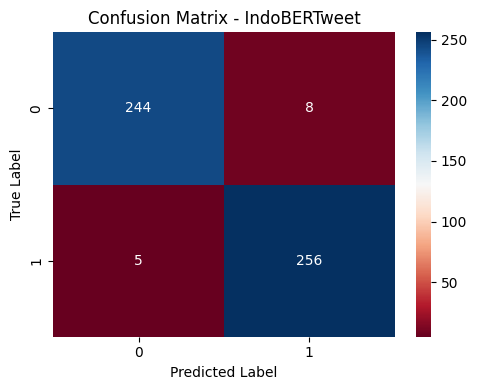

Akurasi model pada data pengujian: 0.9747


In [15]:
model.eval()

predictions, true_labels = [], []
for batch in test_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

    logits = outputs.logits
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    predictions.extend(np.argmax(logits, axis=1).flatten())
    true_labels.extend(label_ids.flatten())

print("\nLaporan Klasifikasi:")
# Laporan yang mencakup Precision, Recall, dan F1-score
print(classification_report(true_labels, predictions))

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu',
            xticklabels=range(model.config.num_labels),
            yticklabels=range(model.config.num_labels))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - IndoBERTweet")
plt.tight_layout()
plt.show()

test_accuracy = accuracy_score(true_labels, predictions)
print(f"Akurasi model pada data pengujian: {test_accuracy:.4f}")

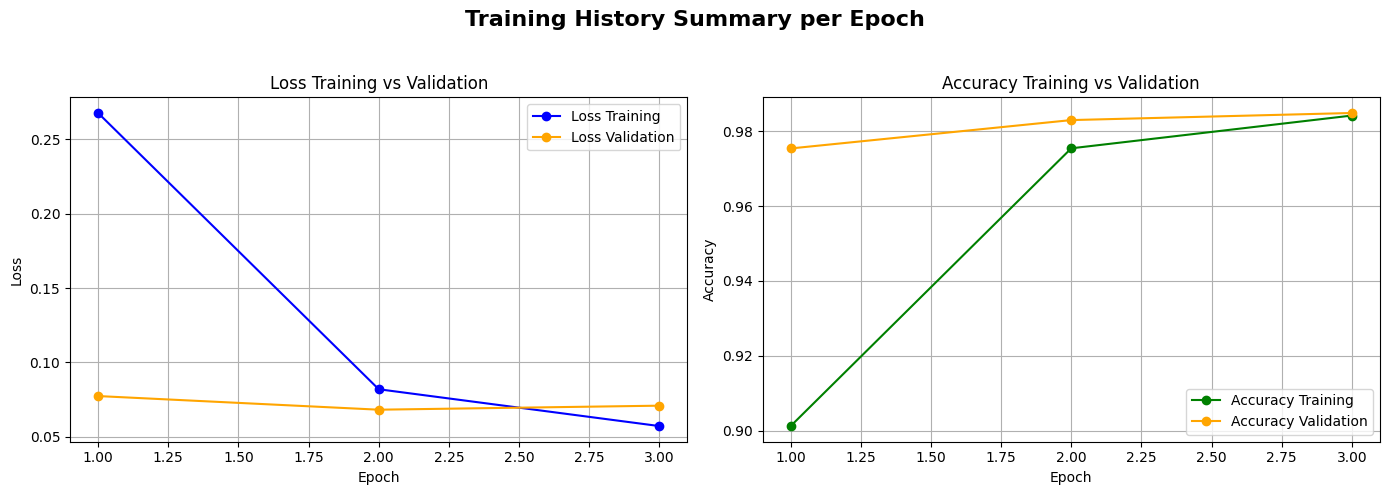

In [16]:
epochs_run = len(history['train_loss'])
epochs_range = range(1, epochs_run + 1)

# Buat 1 baris, 2 kolom plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# === Plot 1: Loss ===
ax1.plot(epochs_range, history['train_loss'], label='Loss Training', color='blue', marker='o')
ax1.plot(epochs_range, history['val_loss'], label='Loss Validation', color='orange', marker='o')
ax1.set_title('Loss Training vs Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# === Plot 2: Accuracy ===
ax2.plot(epochs_range, history['train_acc'], label='Accuracy Training', color='green', marker='o')
ax2.plot(epochs_range, history['val_acc'], label='Accuracy Validation', color='orange', marker='o')
ax2.set_title('Accuracy Training vs Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

# Judul
fig.suptitle('Training History Summary per Epoch', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Error Analisis**

In [17]:
print("\n--- Analisis Sampel Teks yang Salah Diklasifikasikan ---")

sentiment_to_label = {
    'other': 0,
    'non-other': 1
}

# Konversi true_labels dan predictions menjadi array numpy untuk perbandingan
true_labels_np = np.array(true_labels)
predictions_np = np.array(predictions)

# Mencari indeks di mana true_labels tidak sama dengan predictions
misclassified_indices = np.where(true_labels_np != predictions_np)[0]

print(f"Total sampel yang salah diklasifikasikan: {len(misclassified_indices)}")

# Reverse the label mapping to get sentiment strings from labels
label_to_sentiment = {v: k for k, v in sentiment_to_label.items()}

# Creating DataFrame for error analysis
misclassified_data = {
    'Teks': [test_texts.iloc[i] for i in misclassified_indices], # Use iloc for positional indexing
    'True Label (Sentiment)': [label_to_sentiment[true_labels_np[i]] for i in misclassified_indices], # Map label to sentiment
    'Predicted Label (Sentiment)': [label_to_sentiment[predictions_np[i]] for i in misclassified_indices] # Map label to sentiment
}
misclassified_df = pd.DataFrame(misclassified_data)

# Displaying all misclassified samples for further analysis
print("\nMenampilkan semua sampel teks yang salah diklasifikasikan:")
display(misclassified_df.head(12))


--- Analisis Sampel Teks yang Salah Diklasifikasikan ---
Total sampel yang salah diklasifikasikan: 13

Menampilkan semua sampel teks yang salah diklasifikasikan:


,Teks,True Label (Sentiment),Predicted Label (Sentiment)
0,on my way nonton my liberation notes kek sudah...,non-other,other
1,saya malah balik ajar bener prestasi tuntut hi...,non-other,other
2,from living fast to slow ingattt from living f...,other,non-other
3,dulu fikir jugak psl career tapi sekarang saya...,other,non-other
4,slowrep karena slow life itu,non-other,other
5,hidup lambat itu tidak sama dang malas malas h...,non-other,other
6,god is possible takdir bisa ubah doa tapi doa ...,non-other,other
7,ujung ujung saya batas siapa saja masuk hidup ...,other,non-other
8,i know u leave me im slow yasss slowness dalam...,other,non-other
9,dulu saya sering banget main hp sampai lupa wa...,other,non-other


In [18]:
# misclassified_df.to_csv('misclassified_sempel.csv', index=False)

# **Model LSTM**

Langsung lanjut ke deploy model sampai ke tahap evaluasi

In [19]:
np.random.seed(42)
tf.random.set_seed(42)

## **Tokenize Padding**

In [20]:
# Parameters for tokenization and padding
vocab_size = 10000  # Adjust based on your vocabulary size
max_length = 128    # Should be consistent with the BERT model's max_length
embedding_dim = 100 # Dimension of the word embeddings

# Initialize and fit the tokenizer on the training data
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train['stemming'])

# Convert texts to sequences of integers
train_sequences = tokenizer.texts_to_sequences(df_train['stemming'])
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# Pad the sequences
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
val_padded = pad_sequences(val_sequences, maxlen=max_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

print("Data preparation for LSTM complete.")
print("Shape of training data:", train_padded.shape)
print("Shape of validation data:", val_padded.shape)
print("Shape of test data:", test_padded.shape)

Data preparation for LSTM complete.
Shape of training data: (2391, 128)
Shape of validation data: (513, 128)
Shape of test data: (513, 128)


In [21]:
# Calculate class weights to handle potential class imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['skema_label']),
    y=df_train['skema_label']
)

# Convert to dictionary format required by Keras model.fit
class_weights_dict = dict(enumerate(class_weights))

## **Deploy LSTM**

In [22]:
# Define the LSTM model with the specified architecture
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dense(len(np.unique(df_train['skema_label'])), activation='softmax') # Use the number of unique labels from the augmented training data
])

# Compile the model
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Build and summarize the model
model_lstm.build(input_shape=(None, max_length))
model_lstm.summary()

# Callback EarlyStopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("\n--- Memulai Pelatihan LSTM ---")
history_lstm = model_lstm.fit(
    train_padded, df_train['skema_label'], # Use the padded training data and augmented labels
    epochs=20,
    batch_size=16,
    validation_data=(val_padded, val_labels), # Use the padded validation data and validation labels
    class_weight=class_weights_dict, # Use the calculated class weights dictionary
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128, 64)        │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,386 (3.98 MB)

 Trainable params: 1,044,386 (3.98 MB)

 Non-trainable params: 0 (0.00 B)


--- Memulai Pelatihan LSTM ---
Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7084 - loss: 0.5453 - val_accuracy: 0.9474 - val_loss: 0.1562
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9670 - loss: 0.1192 - val_accuracy: 0.9610 - val_loss: 0.1098
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9891 - loss: 0.0616 - val_accuracy: 0.9669 - val_loss: 0.1078
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9956 - loss: 0.0352 - val_accuracy: 0.9513 - val_loss: 0.1739
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9988 - loss: 0.0203 - val_accuracy: 0.9493 - val_loss: 0.2391
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 1.0000 - loss: 0.0166 - val_accuracy: 0.9415 - val_loss: 0.2686
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9999 - loss: 0.0138 - val_accuracy: 0.9513 - val_loss: 0.2597
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 

## **Evaluasi Model**


--- Evaluasi Model LSTM ---
Test Loss: 0.1228
Test Accuracy: 0.9571
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       252
           1       0.95      0.97      0.96       261

    accuracy                           0.96       513
   macro avg       0.96      0.96      0.96       513
weighted avg       0.96      0.96      0.96       513



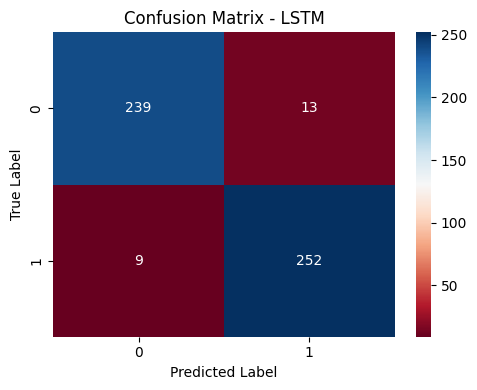

In [23]:
# Evaluate the model on the test data
print("\n--- Evaluasi Model LSTM ---")
test_loss, test_acc = model_lstm.evaluate(test_padded, test_labels, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Get predictions
y_pred = model_lstm.predict(test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(test_labels, y_pred_classes))

# Generate confusion matrix
cm = confusion_matrix(test_labels, y_pred_classes)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu',
            xticklabels=np.unique(test_labels),  # Use unique labels from test set
            yticklabels=np.unique(test_labels))  # Use unique labels from test set
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - LSTM")
plt.tight_layout()
plt.show()

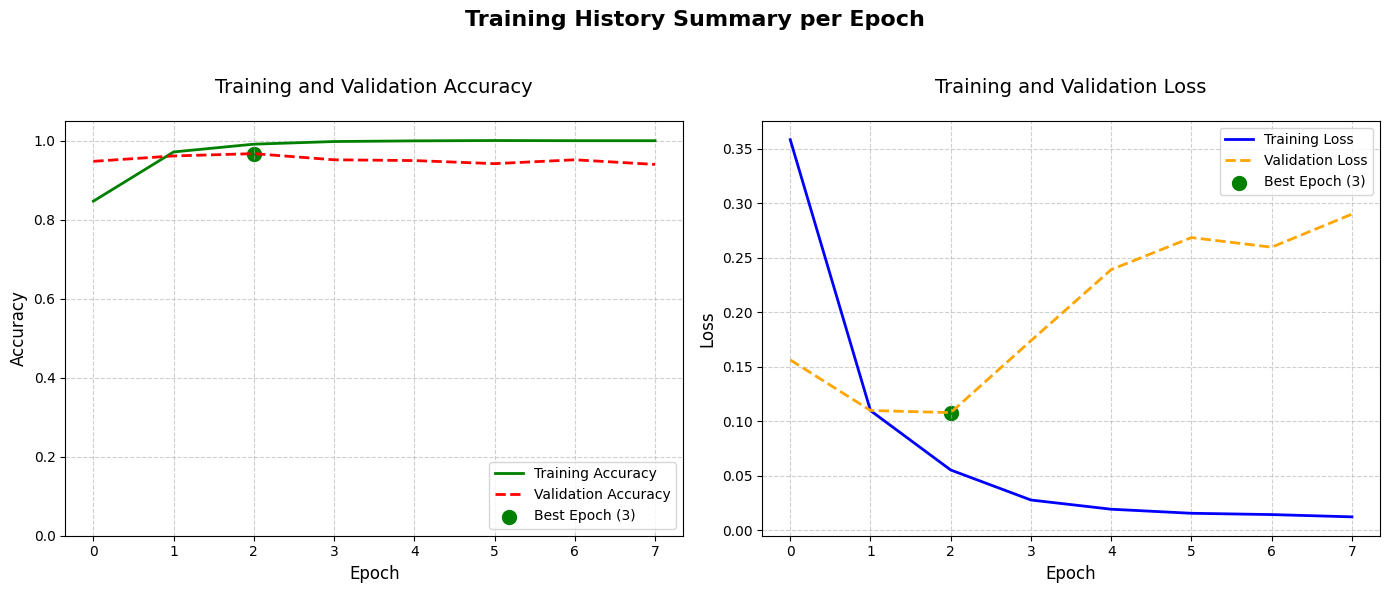

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Get the number of epochs the model actually trained for
num_epochs = len(history_lstm.history['accuracy'])
epochs_range = range(num_epochs)

# Get the best epoch from the EarlyStopping callback
# If early stopping occurred, best_epoch is where performance was best
# If not, the last epoch is the best epoch in terms of performance on the monitored metric during training
if early_stop.stopped_epoch > 0:
    best_epoch = early_stop.best_epoch
else:
    best_epoch = num_epochs - 1 # If no early stopping, the last epoch is technically the "best" among the run epochs


# Plot Accuracy
axes[0].plot(epochs_range, history_lstm.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
axes[0].plot(epochs_range, history_lstm.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
axes[0].scatter(best_epoch, history_lstm.history['val_accuracy'][best_epoch], color='green', s=100, label=f'Best Epoch ({best_epoch + 1})') # Mark the best epoch
axes[0].set_title('Training and Validation Accuracy', fontsize=14, pad=20)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylim([0, 1.05])  # Adjust y-axis limit for better visualization
axes[0].set_xticks(epochs_range) # Set x-ticks to match the number of epochs


# Plot Loss
axes[1].plot(epochs_range, history_lstm.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[1].plot(epochs_range, history_lstm.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
axes[1].scatter(best_epoch, history_lstm.history['val_loss'][best_epoch], color='green', s=100, label=f'Best Epoch ({best_epoch + 1})') # Mark the best epoch
axes[1].set_title('Training and Validation Loss', fontsize=14, pad=20)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xticks(epochs_range) # Set x-ticks to match the number of epochs


# Atur layout dan spacing
fig.suptitle('Training History Summary per Epoch', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# **Model Machine Learning**

In [25]:
print("Total training data:", train_texts.shape[0])

Total training data: 2391


### EDA

/tmp/ipython-input-3058717880.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


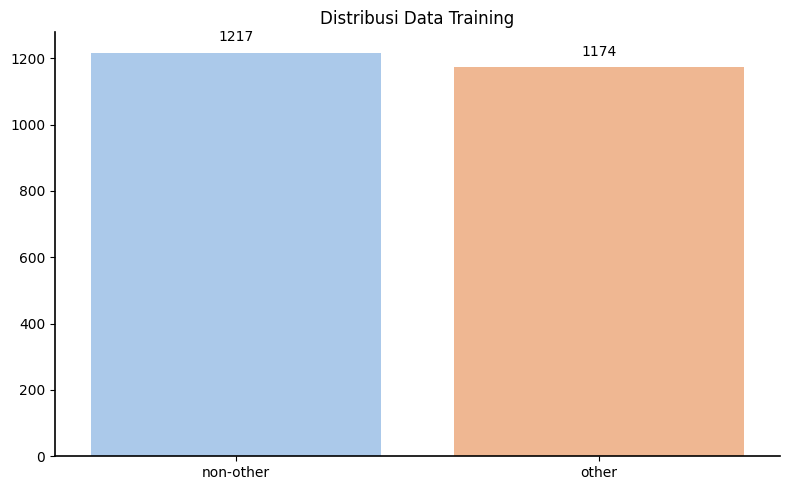

In [26]:
skema_label_to_sentiment = train_labels.value_counts().sort_index()

# Plot minimalis
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

# Hilangkan elemen tambahan
plt.title('Distribusi Data Training')
ax.set_xlabel("")            # Hilangkan label sumbu X
ax.set_ylabel("")            # Hilangkan label sumbu Y
ax.legend([],[], frameon=False)  # Hilangkan legend

# Tambahkan garis sumbu X dan Y saja
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (Opsional) Tambahkan garis dasar sumbu X/Y agar tetap terlihat
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# (Opsional) Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.02, str(value),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### **Ekstraksi Fitur**

Menggunakan BoW, TF-IDF dan N-Grams

In [27]:
vectorizers_bow = {
    'BoW': CountVectorizer(max_features=5000),
}
vectorizers_tfidf = {
    'TFIDF': TfidfVectorizer(max_features=5000),
}
vectorizers_unigram = {
    'Unigram': CountVectorizer(max_features=5000, ngram_range=(1, 1)),
}
vectorizers_bigram = {
    'Bigram': CountVectorizer(max_features=5000, ngram_range=(2, 2)),
}
vectorizers_trigram = {
    'Trigram': CountVectorizer(max_features=5000, ngram_range=(3, 3)),
}

### **Evaluasi Model**

Konfigurasi Model ML

In [28]:
# Inisialisasi model
models = {
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(C=1.0, solver='liblinear', class_weight='balanced',max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=40, min_samples_leaf=3, min_samples_split=2, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=40, min_samples_split=3, min_samples_leaf=3, class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='linear', C=0.5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.05, colsample_bytree=0.8, subsample=0.8, gamma=0.2, eval_metric='mlogloss', random_state=42),
}

BoW


======== Vectorizer: BoW ========

Model: Naive Bayes
Test Accuracy: 0.8577
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84       252
           1       0.80      0.96      0.87       261

    accuracy                           0.86       513
   macro avg       0.87      0.86      0.86       513
weighted avg       0.87      0.86      0.86       513



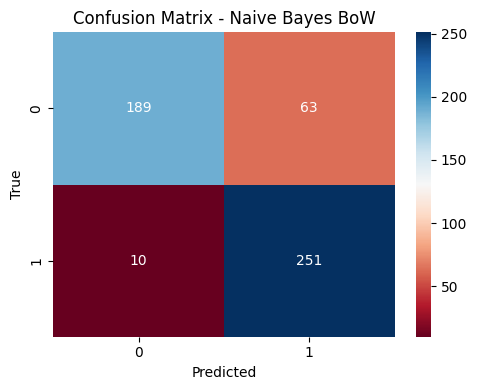


Model: Logistic Regression
Test Accuracy: 0.9552
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       252
           1       0.95      0.96      0.96       261

    accuracy                           0.96       513
   macro avg       0.96      0.96      0.96       513
weighted avg       0.96      0.96      0.96       513



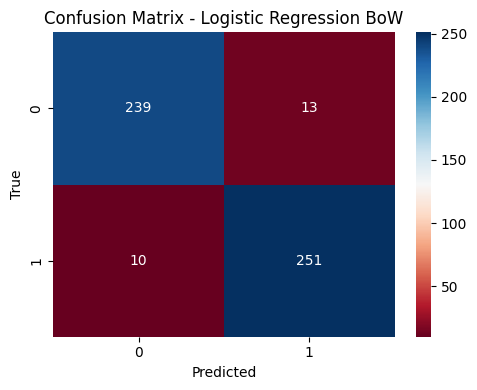


Model: Random Forest
Test Accuracy: 0.9435
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       252
           1       0.92      0.97      0.95       261

    accuracy                           0.94       513
   macro avg       0.95      0.94      0.94       513
weighted avg       0.94      0.94      0.94       513



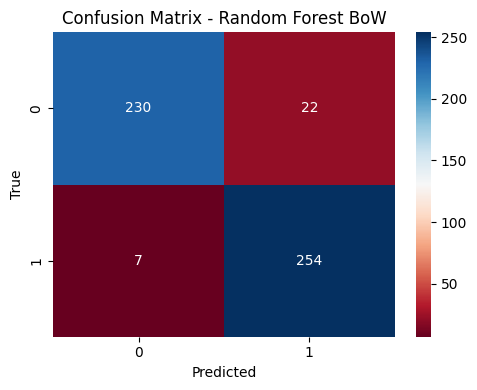


Model: Decision Tree
Test Accuracy: 0.9435
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       252
           1       0.95      0.93      0.94       261

    accuracy                           0.94       513
   macro avg       0.94      0.94      0.94       513
weighted avg       0.94      0.94      0.94       513



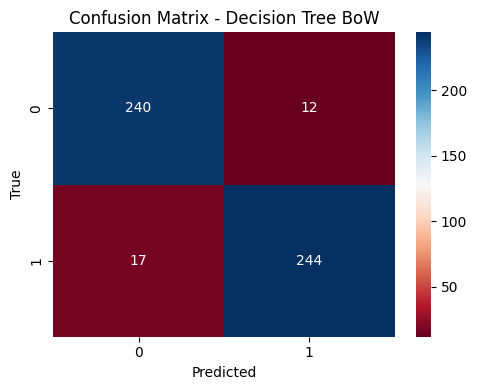


Model: SVM
Test Accuracy: 0.9513
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       252
           1       0.95      0.95      0.95       261

    accuracy                           0.95       513
   macro avg       0.95      0.95      0.95       513
weighted avg       0.95      0.95      0.95       513



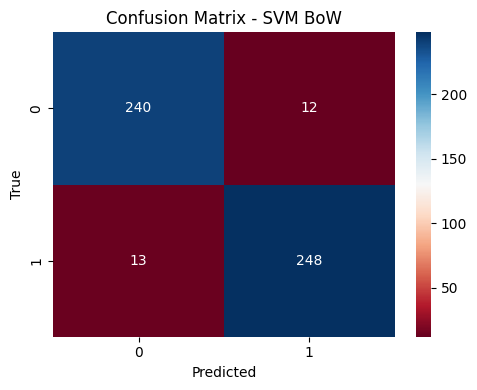


Model: XGBoost
Test Accuracy: 0.9454
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       252
           1       0.95      0.95      0.95       261

    accuracy                           0.95       513
   macro avg       0.95      0.95      0.95       513
weighted avg       0.95      0.95      0.95       513



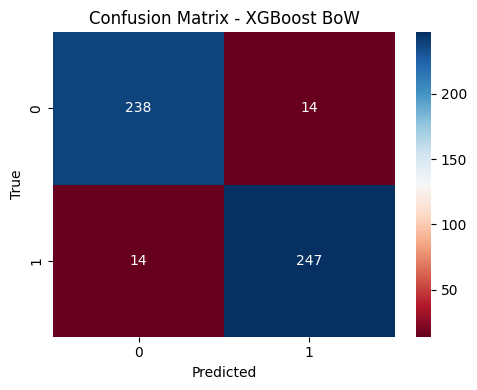

In [29]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_bow.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


TF-IDF


======== Vectorizer: TFIDF ========

Model: Naive Bayes
Test Accuracy: 0.8070
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.69      0.78       252
           1       0.75      0.92      0.83       261

    accuracy                           0.81       513
   macro avg       0.82      0.80      0.80       513
weighted avg       0.82      0.81      0.80       513



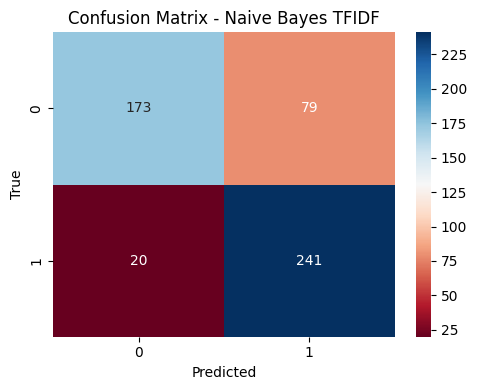


Model: Logistic Regression
Test Accuracy: 0.9591
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       252
           1       0.97      0.95      0.96       261

    accuracy                           0.96       513
   macro avg       0.96      0.96      0.96       513
weighted avg       0.96      0.96      0.96       513



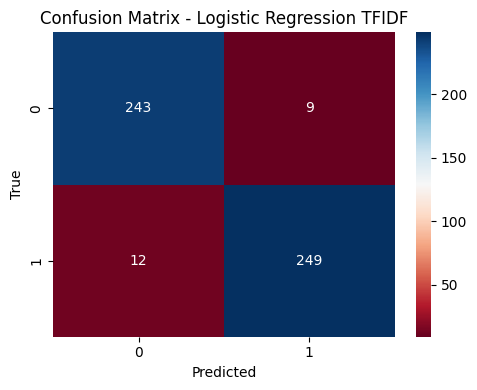


Model: Random Forest
Test Accuracy: 0.9454
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       252
           1       0.92      0.98      0.95       261

    accuracy                           0.95       513
   macro avg       0.95      0.94      0.95       513
weighted avg       0.95      0.95      0.95       513



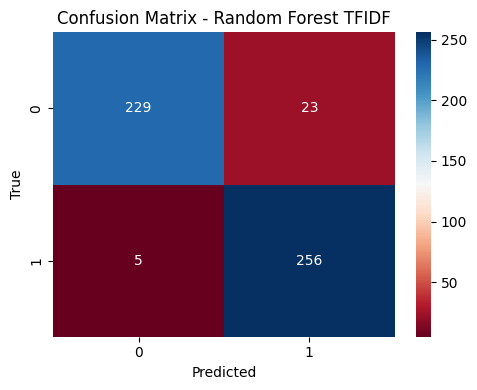


Model: Decision Tree
Test Accuracy: 0.9259
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       252
           1       0.93      0.93      0.93       261

    accuracy                           0.93       513
   macro avg       0.93      0.93      0.93       513
weighted avg       0.93      0.93      0.93       513



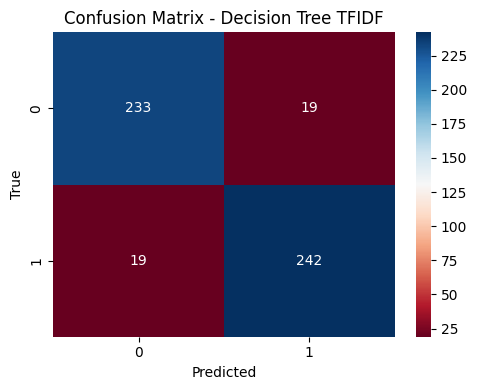


Model: SVM
Test Accuracy: 0.9571
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       252
           1       0.96      0.96      0.96       261

    accuracy                           0.96       513
   macro avg       0.96      0.96      0.96       513
weighted avg       0.96      0.96      0.96       513



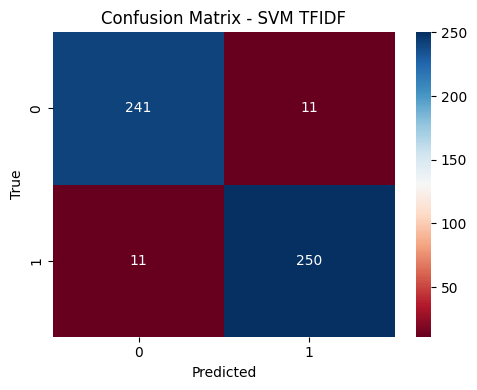


Model: XGBoost
Test Accuracy: 0.9493
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       252
           1       0.94      0.97      0.95       261

    accuracy                           0.95       513
   macro avg       0.95      0.95      0.95       513
weighted avg       0.95      0.95      0.95       513



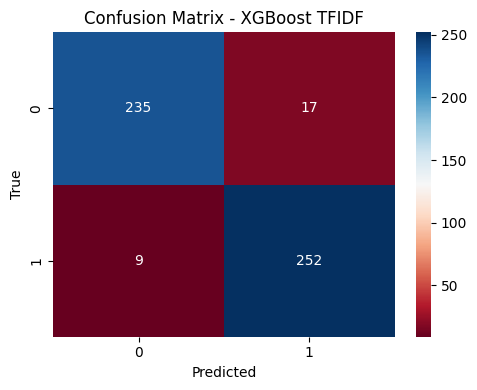

In [30]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_tfidf.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


Uni Gram


======== Vectorizer: Unigram ========

Model: Naive Bayes
Test Accuracy: 0.8577
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84       252
           1       0.80      0.96      0.87       261

    accuracy                           0.86       513
   macro avg       0.87      0.86      0.86       513
weighted avg       0.87      0.86      0.86       513



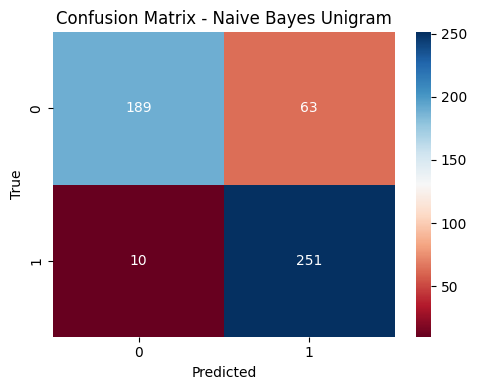


Model: Logistic Regression
Test Accuracy: 0.9552
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       252
           1       0.95      0.96      0.96       261

    accuracy                           0.96       513
   macro avg       0.96      0.96      0.96       513
weighted avg       0.96      0.96      0.96       513



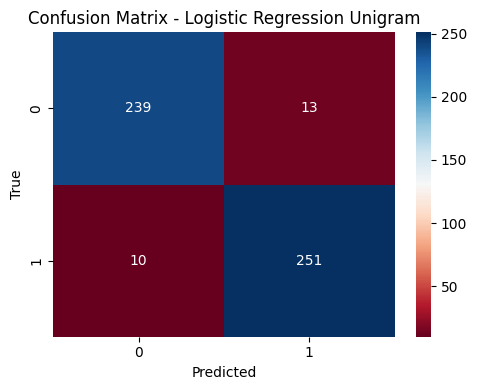


Model: Random Forest
Test Accuracy: 0.9435
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       252
           1       0.92      0.97      0.95       261

    accuracy                           0.94       513
   macro avg       0.95      0.94      0.94       513
weighted avg       0.94      0.94      0.94       513



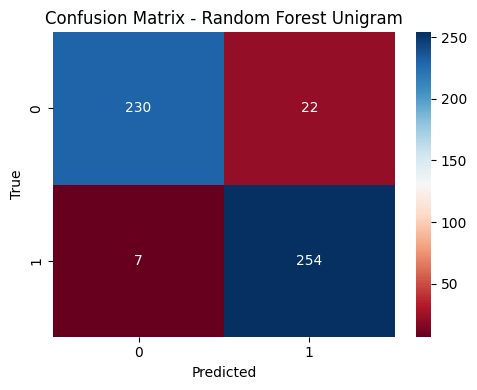


Model: Decision Tree
Test Accuracy: 0.9435
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       252
           1       0.95      0.93      0.94       261

    accuracy                           0.94       513
   macro avg       0.94      0.94      0.94       513
weighted avg       0.94      0.94      0.94       513



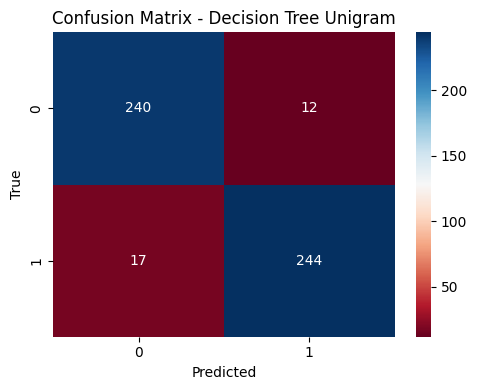


Model: SVM
Test Accuracy: 0.9513
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       252
           1       0.95      0.95      0.95       261

    accuracy                           0.95       513
   macro avg       0.95      0.95      0.95       513
weighted avg       0.95      0.95      0.95       513



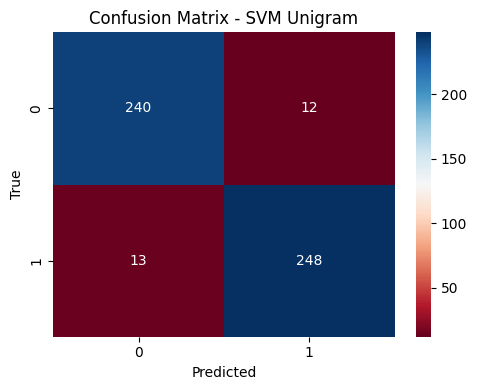


Model: XGBoost
Test Accuracy: 0.9454
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       252
           1       0.95      0.95      0.95       261

    accuracy                           0.95       513
   macro avg       0.95      0.95      0.95       513
weighted avg       0.95      0.95      0.95       513



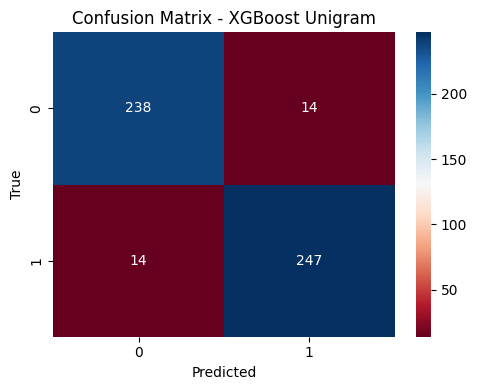

In [31]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_unigram.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


Bi Gram


======== Vectorizer: Bigram ========

Model: Naive Bayes
Test Accuracy: 0.6764
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.36      0.52       252
           1       0.61      0.98      0.76       261

    accuracy                           0.68       513
   macro avg       0.79      0.67      0.64       513
weighted avg       0.78      0.68      0.64       513



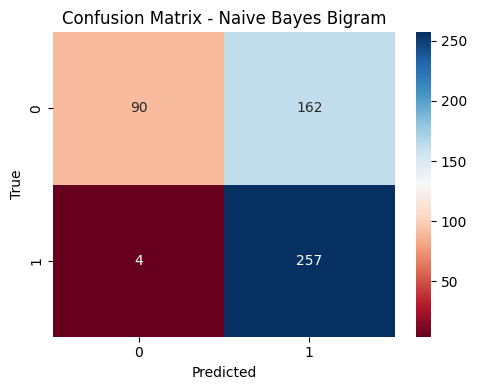


Model: Logistic Regression
Test Accuracy: 0.9766
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       252
           1       0.99      0.96      0.98       261

    accuracy                           0.98       513
   macro avg       0.98      0.98      0.98       513
weighted avg       0.98      0.98      0.98       513



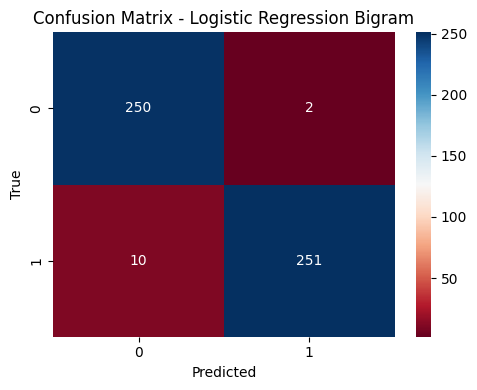


Model: Random Forest
Test Accuracy: 0.9669
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       252
           1       1.00      0.93      0.97       261

    accuracy                           0.97       513
   macro avg       0.97      0.97      0.97       513
weighted avg       0.97      0.97      0.97       513



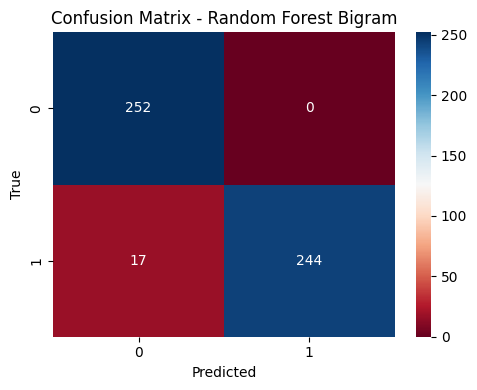


Model: Decision Tree
Test Accuracy: 0.9805
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       252
           1       0.99      0.97      0.98       261

    accuracy                           0.98       513
   macro avg       0.98      0.98      0.98       513
weighted avg       0.98      0.98      0.98       513



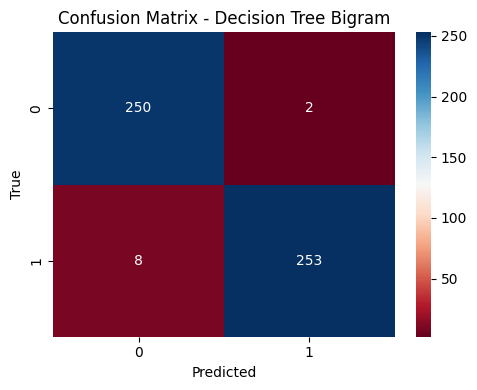


Model: SVM
Test Accuracy: 0.9805
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       252
           1       0.99      0.97      0.98       261

    accuracy                           0.98       513
   macro avg       0.98      0.98      0.98       513
weighted avg       0.98      0.98      0.98       513



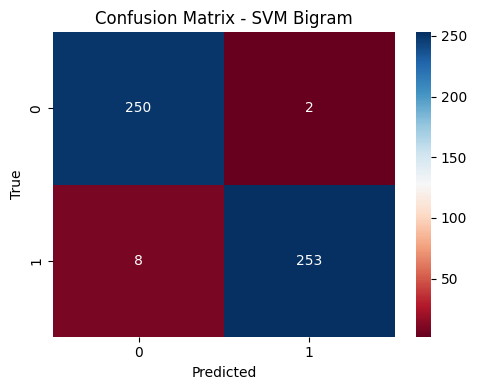


Model: XGBoost
Test Accuracy: 0.9825
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       252
           1       0.99      0.97      0.98       261

    accuracy                           0.98       513
   macro avg       0.98      0.98      0.98       513
weighted avg       0.98      0.98      0.98       513



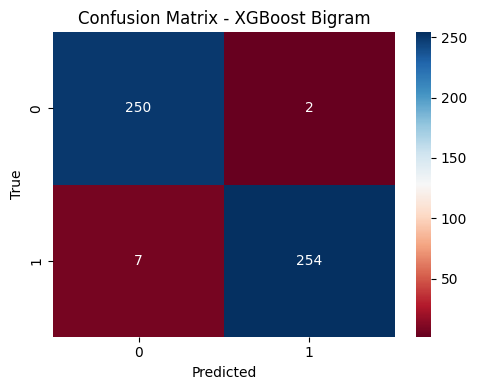

In [32]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_bigram.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

Tri Gram


======== Vectorizer: Trigram ========

Model: Naive Bayes
Test Accuracy: 0.5575
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.11      0.19       252
           1       0.54      0.99      0.70       261

    accuracy                           0.56       513
   macro avg       0.73      0.55      0.44       513
weighted avg       0.73      0.56      0.45       513



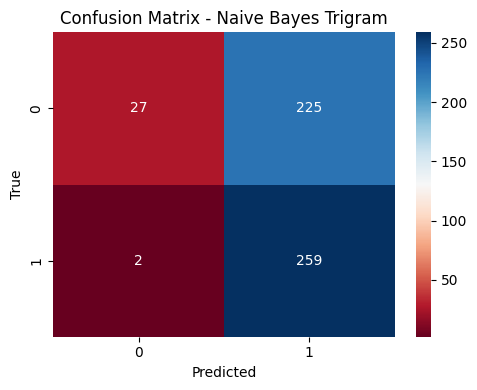


Model: Logistic Regression
Test Accuracy: 0.8109
Classification Report:
              precision    recall  f1-score   support

           0       0.72      1.00      0.84       252
           1       1.00      0.63      0.77       261

    accuracy                           0.81       513
   macro avg       0.86      0.81      0.81       513
weighted avg       0.86      0.81      0.80       513



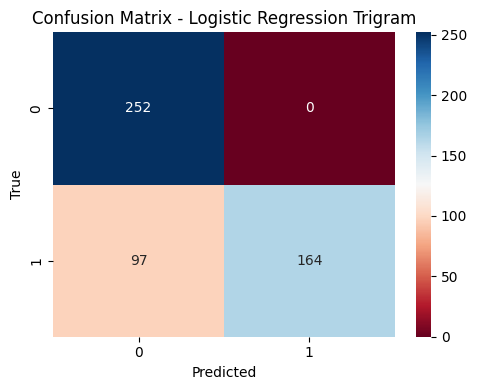


Model: Random Forest
Test Accuracy: 0.7583
Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80       252
           1       1.00      0.52      0.69       261

    accuracy                           0.76       513
   macro avg       0.84      0.76      0.75       513
weighted avg       0.84      0.76      0.74       513



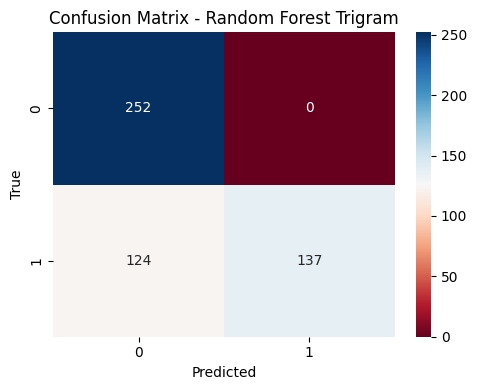


Model: Decision Tree
Test Accuracy: 0.7407
Classification Report:
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       252
           1       1.00      0.49      0.66       261

    accuracy                           0.74       513
   macro avg       0.83      0.75      0.72       513
weighted avg       0.83      0.74      0.72       513



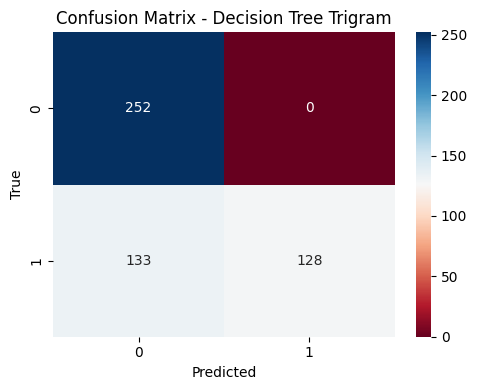


Model: SVM
Test Accuracy: 0.8051
Classification Report:
              precision    recall  f1-score   support

           0       0.72      1.00      0.83       252
           1       1.00      0.62      0.76       261

    accuracy                           0.81       513
   macro avg       0.86      0.81      0.80       513
weighted avg       0.86      0.81      0.80       513



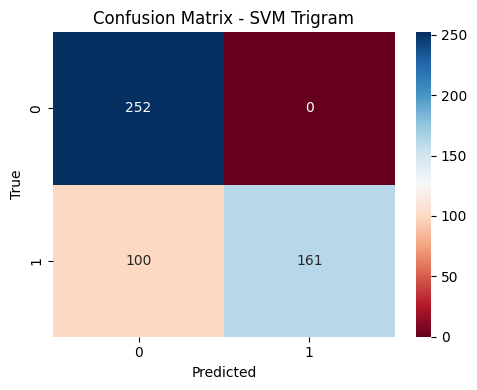


Model: XGBoost
Test Accuracy: 0.7622
Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.81       252
           1       1.00      0.53      0.69       261

    accuracy                           0.76       513
   macro avg       0.84      0.77      0.75       513
weighted avg       0.84      0.76      0.75       513



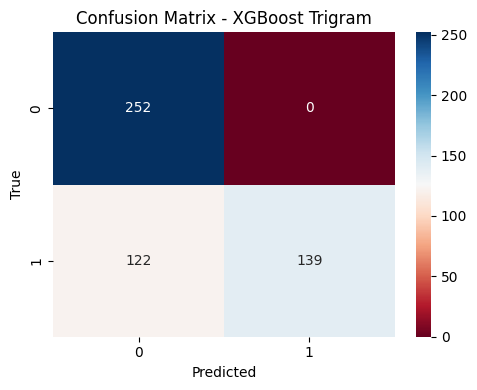

In [33]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_trigram.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


### analisis error klasifikasi

In [34]:
from collections import defaultdict

# Initialize dictionaries to store vectorized data for each method
X_train_vecs = {}
X_test_vecs = {}

# Process each vectorizer
for vec_name, vectorizer in {**vectorizers_bow, **vectorizers_tfidf, **vectorizers_unigram, **vectorizers_bigram, **vectorizers_trigram}.items():

    # Transform texts and store
    X_train_vecs[vec_name] = vectorizer.fit_transform(train_texts)
    X_test_vecs[vec_name] = vectorizer.transform(test_texts)

# Mengumpulkan semua prediksi dari berbagai model dan metode ekstraksi fitur
all_predictions = {}

for vec_name in X_train_vecs.keys():
    X_train_vec = X_train_vecs[vec_name]
    X_test_vec = X_test_vecs[vec_name]

    for model_name, model in models.items():
        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        all_predictions[f"{vec_name}_{model_name.replace(' ', '_')}"] = y_pred


# Hitung berapa kali setiap data diuji salah oleh model
incorrect_predictions_count = defaultdict(int)
num_models = len(all_predictions)

# Get the original indices from the test set
test_indices = test_labels.index

for model_name, predictions in all_predictions.items():
    # Ensure predictions have the same length and index as the test set
    if len(predictions) != len(test_indices):
        print(f"Warning: Length mismatch for model {model_name}. Skipping...")
        continue

    for i, original_index in enumerate(test_indices):
        if predictions[i] != test_labels.loc[original_index]: # Compare with the correct test label
            incorrect_predictions_count[original_index] += 1

# Urutkan data berdasarkan jumlah prediksi yang salah secara menurun
sorted_incorrect_predictions = sorted(incorrect_predictions_count.items(), key=lambda item: item[1], reverse=True)

# Ambil 10 data teratas yang paling sering salah diprediksi
top_10_difficult_data_indices = [index for index, count in sorted_incorrect_predictions[:10]]

print("\n10 Data Teratas yang Sulit Diklasifikasikan:")
for i, index in enumerate(top_10_difficult_data_indices):
    # Pastikan indeks ada di dataframe asli sebelum slicing
    if index in df.index:
        print(f"\nData ke-{i+1} (Indeks asli: {index}):")
        print(f"  Sentiment Asli: {df.loc[index, 'sentiment']}")
        print(f"  Stemming: {df.loc[index, 'stemming']}")
        print(f"  Jumlah Model yang Salah Prediksi: {incorrect_predictions_count[index]}")
    else:
        print(f"\nIndeks {index} tidak ditemukan di DataFrame asli. Mungkin ada masalah dengan sinkronisasi indeks.")


10 Data Teratas yang Sulit Diklasifikasikan:

Data ke-1 (Indeks asli: 2661):
  Sentiment Asli: netral
  Stemming: hidup lambat itu tidak sama dang malas malas hidup lambat tetap laku banyak hal tapi pola lambat lebih santai pilih hidup lambat tidak harus repot orang lain
  Jumlah Model yang Salah Prediksi: 25

Data ke-2 (Indeks asli: 577):
  Sentiment Asli: positif
  Stemming: god is possible takdir bisa ubah doa tapi doa tanpa buat itu mati just living your best life to achieve your dream even tho it is just small dream
  Jumlah Model yang Salah Prediksi: 25

Data ke-3 (Indeks asli: 2897):
  Sentiment Asli: positif
  Stemming: on my way nonton my liberation notes kek sudah kali mau nyerah karena buset bnr slow pace banget slice of life banget latar jauh bener cuman rumah kantor bis ladang kebun cafe can imagine doyan jegar jeger pasti tidak sanggup nonton yak itu tapi sudah eps
  Jumlah Model yang Salah Prediksi: 23

Data ke-4 (Indeks asli: 2146):
  Sentiment Asli: positif
  Stemming